In [5]:
k = "What's up my fellow colon lovers!!"
print(k)

What's up my fellow colon lovers!!


In [2]:
import tensorflow as tf
import numpy as np

# CONFIG
data_dir = "dataset"
img_size = (48, 48)
batch_size = 32
seed = 123
epochs = 20

# LOAD DATA (train/val split automatically)
train_data = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

val_data = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_data.class_names
print("Classes:", class_names)


# NORMALISATION 
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_data = train_data.map(lambda x, y: (normalization_layer(x), y))
val_data = val_data.map(lambda x, y: (normalization_layer(x), y))

# speed optimisation
AUTOTUNE = tf.data.AUTOTUNE
train_data = train_data.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_data = val_data.cache().prefetch(buffer_size=AUTOTUNE)


# DATA AUGMENTATION
data_augmentation = tf.keras.Sequential([
   tf.keras.layers.RandomFlip("horizontal"),
   tf.keras.layers.RandomRotation(0.03),
   tf.keras.layers.RandomZoom(0.05)
])

# -------------------
# MODEL (CNN)
# -------------------
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(48, 48, 3)),

    # Block 1
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.25),

    # Block 2
    tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.25),

    # Block 3
    tf.keras.layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.4),

    # Head
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(3, activation='softmax')
])

# -------------------
# COMPILE
# -------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# Define early stopping (THIS GOES BEFORE FIT)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[early_stop]
)

# -------------------
# SAVE MODEL
# -------------------
model.save("emotion_cnn_model.h5")



# Example:
# predict_image("test.jpg")

Found 16095 files belonging to 3 classes.
Using 12876 files for training.
Found 16095 files belonging to 3 classes.
Using 3219 files for validation.
Classes: ['angry', 'happy', 'sad']
Epoch 1/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 147s 210ms/step - accuracy: 0.4559 - loss: 1.2888 - val_accuracy: 0.5197 - val_loss: 1.0240
Epoch 2/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 67s 166ms/step - accuracy: 0.5867 - loss: 0.8903 - val_accuracy: 0.4290 - val_loss: 1.0596
Epoch 3/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 65s 161ms/step - accuracy: 0.6525 - loss: 0.7619 - val_accuracy: 0.6872 - val_loss: 0.7115
Epoch 4/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 66s 163ms/step - accuracy: 0.6905 - loss: 0.6945 - val_accuracy: 0.7064 - val_loss: 0.6789
Epoch 5/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 69s 172ms/step - accuracy: 0.7104 - loss: 0.6549 - val_accuracy: 0.7344 - val_loss: 0.6158
Epoch 6/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 63s 157ms/step - accuracy: 0.7345 - loss: 0.6181 - val_accuracy: 0.7425 - val_loss: 0.6186
Epoch 7/30
403/403 ━━━━━━━━━━

In [3]:
import tensorflow as tf
import numpy as np
from PIL import Image

# -------------------
# CONFIG
# -------------------
data_dir = "dataset"
img_size = (48, 48)
batch_size = 32
seed = 123
epochs = 20

train_data = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

model = tf.keras.models.load_model("emotion_cnn_model.h5")
class_names = train_data.class_names

# -------------------
# PREDICT SINGLE IMAGE
# -------------------
def predict_image(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=img_size)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array)[0]
    predicted_class = class_names[np.argmax(predictions)]

    print("Prediction:", predicted_class)
    print("Confidence, [angry, happy, sad]:", predictions)


predict_image("dataset/happy/265.jpg")

Found 16095 files belonging to 3 classes.
Using 12876 files for training.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step
Prediction: happy
Confidence, [angry, happy, sad]: [0.11875353 0.86672467 0.01452181]


Found 16095 files belonging to 3 classes.
Using 3219 files for validation.
101/101 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - accuracy: 0.7754 - loss: 0.5376
Validation Loss: 0.5375596284866333
Validation Accuracy: 0.7753961086273193
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━

<Figure size 640x480 with 0 Axes>

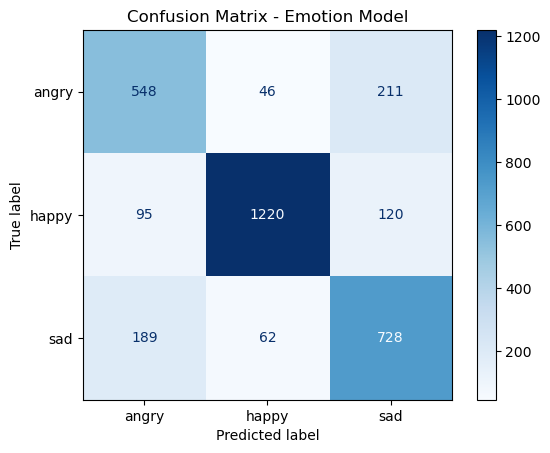

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# -------------------
# CONFIG
# -------------------
data_dir = "dataset"
img_size = (48, 48)
batch_size = 32
seed = 123

# -------------------
# LOAD MODEL
# -------------------
model = tf.keras.models.load_model("1_CNN_model.h5")

# -------------------
# LOAD DATA AGAIN (same split as training)
# -------------------
val_data = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True
)

class_names = val_data.class_names

# normalize
normalization_layer = tf.keras.layers.Rescaling(1./255)
val_data = val_data.map(lambda x, y: (normalization_layer(x), y))

# -------------------
# EVALUATION
# -------------------
loss, acc = model.evaluate(val_data)
print("Validation Loss:", loss)
print("Validation Accuracy:", acc)

# -------------------
# PREDICTIONS
# -------------------
y_true = []
y_pred = []

for images, labels in val_data:
    preds = model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

# -------------------
# CONFUSION MATRIX
# -------------------
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure()
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Emotion Model")
plt.show()

In [5]:
from sklearn.metrics import classification_report, accuracy_score

acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {acc:.4f} ({acc*100:.1f}%)\n")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

Test Accuracy: 0.7754 (77.5%)

              precision    recall  f1-score   support

       angry       0.66      0.68      0.67       805
       happy       0.92      0.85      0.88      1435
         sad       0.69      0.74      0.71       979

    accuracy                           0.78      3219
   macro avg       0.75      0.76      0.76      3219
weighted avg       0.78      0.78      0.78      3219

